In [24]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [13]:
df = pd.read_csv('academic_meals_elementary_district.csv')

In [16]:
ses_cols = ['student_low_income_percent', 'student_disabilities_percent']
hei_total_col = 'HEI 2015 Total Score'
hei_components_cols = [
    'HEI 2015 Total Fruits (0-5)',
    'HEI 2015 Total Vegetables (0-5)',
    'HEI 2015 Whole Grains (0-10)',
    'HEI 2015 Dairy (0-10)',
    'HEI 2015 Total Protein Foods (0-5)',
    'HEI 2015 Seafood and Plant Proteins (0-5)',
    'HEI 2015 Fatty Acids (0-10)',
    'HEI 2015 Refined Grains (0-10)',
    'HEI 2015 Sodium (0-10)',
    'HEI 2015 Added Sugars (0-10)',
    'HEI 2015 Saturated Fats (0-10)'
]
target = 'ELA_Proficiency'

all_vars = ses_cols + [hei_total_col] + hei_components_cols + [target]
df_clean = df[all_vars].dropna()

In [32]:
# model 1 SES only
X1 = sm.add_constant(df_clean[ses_cols])
model1 = sm.OLS(df_clean[target], X1).fit()
print("Model 1 Baseline R²:", model1.rsquared)
print("\nCoefficients:\n", model1.params)
print("\nP-values:\n", model1.pvalues)


Model 1 Baseline R²: 0.6530039722748759

Coefficients:
 const                           82.702092
student_low_income_percent      -0.527330
student_disabilities_percent    -0.438537
dtype: float64

P-values:
 const                           1.555102e-13
student_low_income_percent      4.623508e-12
student_disabilities_percent    3.423139e-01
dtype: float64


In [35]:
# model 2 add overall nutrition
X2 = sm.add_constant(df_clean[ses_cols + [hei_total_col]])
model2 = sm.OLS(df_clean[target], X2).fit()
print("Model 2 Adjusted R²:", model2.rsquared_adj)
hei_coef = model2.params[hei_total_col]
hei_p = model2.pvalues[hei_total_col]

print("HEI Total Score Coefficient: ", hei_coef, "\np-value: ", hei_p)

Model 2 Adjusted R²: 0.6571916970080094
HEI Total Score Coefficient:  -0.3971385636455321 
p-value:  0.06299123812996063


In [38]:
def partial_f_test(reduced, full):
    ssr_r, ssr_f = reduced.ssr, full.ssr
    df_r, df_f = reduced.df_resid, full.df_resid
    f_stat = ((ssr_r - ssr_f) / (df_r - df_f)) / (ssr_f / df_f)
    p_val = stats.f.sf(f_stat, df_r - df_f, df_f)
    return f_stat, p_val

f_val, p_val = partial_f_test(model1, model2)
print("Partial F-test M1 vs M2: ", "F=", f_val, "p=", p_val)

Partial F-test M1 vs M2:  F= 3.6230128019821923 p= 0.06299123812996062


In [41]:
# model 3 HEI components
X3 = sm.add_constant(df_clean[ses_cols + hei_components_cols])
model3 = sm.OLS(df_clean[target], X3).fit()
print("Model 3 (Components) R²:", model3.rsquared, "\n")

significant_vars = model3.pvalues[model3.pvalues < 0.05]
for var, p in significant_vars.items():
    coef = model3.params[var]
    print(var, "Coef: ", coef, "p-value: ", p)

# Check VIF
vif = pd.DataFrame()
vif["Feature"] = X3.columns
vif["VIF"] = [variance_inflation_factor(X3.values, i) for i in range(X3.shape[1])]
print("\nVIF Check for Model 3:")
print(vif)


Model 3 (Components) R²: 0.7826918140089844 

const Coef:  95.61125829313693 p-value:  0.0006300164974909284
student_low_income_percent Coef:  -0.43626547071237165 p-value:  1.021201411454134e-08
HEI 2015 Total Fruits (0-5) Coef:  -3.181133911197718 p-value:  0.04856786356398355
HEI 2015 Saturated Fats (0-10) Coef:  3.997100551875694 p-value:  0.023340586220751896

VIF Check for Model 3:
                                      Feature         VIF
0                                       const  291.218358
1                  student_low_income_percent    1.389651
2                student_disabilities_percent    1.212072
3                 HEI 2015 Total Fruits (0-5)    2.464008
4             HEI 2015 Total Vegetables (0-5)    2.395389
5                HEI 2015 Whole Grains (0-10)    2.155814
6                       HEI 2015 Dairy (0-10)    3.238750
7          HEI 2015 Total Protein Foods (0-5)    2.986794
8   HEI 2015 Seafood and Plant Proteins (0-5)    3.767248
9                 HEI 2015 Fa

In [22]:
summary = pd.DataFrame({
    "Model": ["M1: SES", "M2: Total HEI", "M3: HEI Components"],
    "R2": [model1.rsquared, model2.rsquared, model3.rsquared],
    "Adj_R2": [model1.rsquared_adj, model2.rsquared_adj, model3.rsquared_adj]
})
print(summary)

                Model        R2    Adj_R2
0             M1: SES  0.653004  0.638841
1       M2: Total HEI  0.677357  0.657192
2  M3: HEI Components  0.782692  0.708350


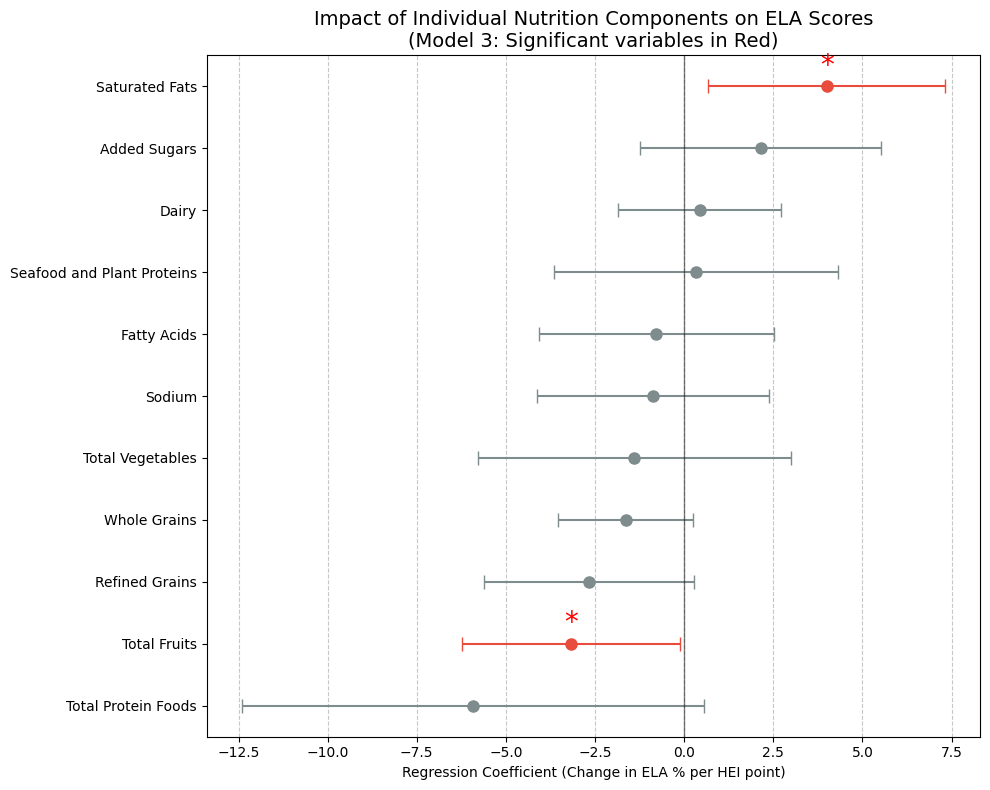

In [27]:
def plot_forest_nutrition():
    params = model3.params[hei_components_cols]
    errors = model3.bse[hei_components_cols] * 1.96  
    pvals = model3.pvalues[hei_components_cols]
    
    clean_names = [c.replace('HEI 2015 ', '').replace(' (0-5)', '').replace(' (0-10)', '') for c in params.index]
    
    plot_df = pd.DataFrame({
        'Name': clean_names,
        'Coef': params.values,
        'Err': errors.values,
        'Pval': pvals.values
    }).sort_values('Coef')

    plt.figure(figsize=(10, 8))
    
    for i in range(len(plot_df)):
        color = '#e74c3c' if plot_df.iloc[i]['Pval'] < 0.05 else '#7f8c8d'
        plt.errorbar(plot_df.iloc[i]['Coef'], i, xerr=plot_df.iloc[i]['Err'], 
                     fmt='o', color=color, ecolor=color, capsize=5, markersize=8)
        
        if plot_df.iloc[i]['Pval'] < 0.05:
            plt.text(plot_df.iloc[i]['Coef'], i + 0.2, '*', color='red', fontsize=20, ha='center')

    plt.axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)
    plt.yticks(range(len(plot_df)), plot_df['Name'])
    plt.title('Impact of Individual Nutrition Components on ELA Scores\n(Model 3: Significant variables in Red)', fontsize=14)
    plt.xlabel('Regression Coefficient (Change in ELA % per HEI point)')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.savefig('nutrition_forest_plot.png', dpi=300)
    plt.show()

plot_forest_nutrition()

**Model 1: The Baseline (SES Only)**
It analyzes the influence of poverty (low_income_percent) and disability rates.

Result: SES alone explains approximately 65% of the variance in academic scores.


**Model 2: Macro Nutrition**
It adds the HEI 2015 Total Score to the baseline.

Result: Shows a marginal improvement ($p = 0.063$), suggesting that an overall score may be too broad to capture specific dietary impacts.


**Model 3: Detailed Nutritional Components**
We breaks down nutrition into 11 specific components (e.g., Whole Fruits, Refined Grains, Sodium, etc.).

Result: Model accuracy ($R^2$) increases to 78%, identifying specific dietary "drivers" of academic performance.

**The reduction in the negative impact of poverty.**
- In Model 1, the coefficient for low-income status was highly negative.

- In Model 3 (controlling for specific nutrients), this negative impact was reduced by approximately 17%.

**When the HEI index was broken down, two components emerged as statistically significant contributors to higher ELA scores**
- Total Fruits: Higher fruit intake is directly correlated with improved district-wide proficiency.

- Saturated Fats Score: Districts with lower saturated fat consumption in school meals demonstrated significantly higher academic performance.